# EEG Biomarkers of Mind Wandering vs Focused Meditation

This notebook replicates and extends **Brandmeyer & Delorme (2018)** by comparing EEG spectral power, frontal alpha asymmetry, and functional connectivity between self-reported **mind wandering** and **focused attention** states during meditation.

**Dataset:** OpenNeuro ds001787 — 24 subjects, 2 sessions each  
**Response codes:** `2` = Mind Wandering, `4` = Focused Attention  
**Reference:** Brandmeyer, T., & Delorme, A. (2018). Reduced mind wandering in experienced meditators and associated EEG correlates. *Experimental Brain Research*, 236(9), 2519–2528. https://doi.org/10.1007/s00221-016-4811-5

---
## Pipeline Overview
1. Load & preprocess raw BDF files (filtering, channel fixing, epoching)
2. Split epochs by response condition (mind wandering vs focused)
3. Compare EEG band power between conditions
4. Compute Frontal Alpha Asymmetry (FAA) — a wellbeing biomarker
5. Compute Alpha band functional connectivity (PLV)
6. Visualize **statistically significant** connectivity changes as a connectome

---
Munna R. Shainy [[Find me on LinkedIn]](https://www.linkedin.com/in/munnars/)  
Year: 2026

## 1. Imports & Setup

In [16]:
import os
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
from mne_connectivity import spectral_connectivity_epochs
from mne_connectivity.viz import plot_connectivity_circle

sns.set_theme(style='whitegrid')
mne.set_log_level('WARNING')

os.makedirs('figures', exist_ok=True)

## 2. Parameters

All key parameters are defined here in one place — easy to audit and modify.

The BioSemi ActiveTwo system labels channels A1–B32. These don't match the standard 10-20 nomenclature MNE expects for montage assignment, so we rename them using the standard BioSemi 64-channel mapping.

In [2]:
# BioSemi A1-B32 to standard 10-20 channel name mapping
biosemi_to_standard = {
    'A1': 'Fp1', 'A2': 'AF7', 'A3': 'AF3', 'A4': 'F1',
    'A5': 'F3',  'A6': 'F5',  'A7': 'F7',  'A8': 'FT7',
    'A9': 'FC5', 'A10': 'FC3','A11': 'FC1','A12': 'C1',
    'A13': 'C3', 'A14': 'C5', 'A15': 'T7', 'A16': 'TP7',
    'A17': 'CP5','A18': 'CP3','A19': 'CP1','A20': 'P1',
    'A21': 'P3', 'A22': 'P5', 'A23': 'P7', 'A24': 'P9',
    'A25': 'PO7','A26': 'PO3','A27': 'O1', 'A28': 'Iz',
    'A29': 'Oz', 'A30': 'POz','A31': 'Pz', 'A32': 'CPz',
    'B1': 'Fpz', 'B2': 'Fp2', 'B3': 'AF8', 'B4': 'AF4',
    'B5': 'AFz', 'B6': 'Fz',  'B7': 'F2',  'B8': 'F4',
    'B9': 'F6',  'B10': 'F8', 'B11': 'FT8','B12': 'FC6',
    'B13': 'FC4','B14': 'FC2','B15': 'FCz','B16': 'Cz',
    'B17': 'C2', 'B18': 'C4', 'B19': 'C6', 'B20': 'T8',
    'B21': 'TP8','B22': 'CP6','B23': 'CP4','B24': 'CP2',
    'B25': 'P2', 'B26': 'P4', 'B27': 'P6', 'B28': 'P8',
    'B29': 'P10','B30': 'PO8','B31': 'PO4','B32': 'O2'
}

# Non-EEG channels — must be retyped to prevent false artifact rejection
non_eeg_channel_types = {
    'EXG1': 'eog', 'EXG2': 'eog', 'EXG3': 'eog', 'EXG4': 'eog',
    'EXG5': 'eog', 'EXG6': 'eog', 'EXG7': 'eog', 'EXG8': 'eog',
    'GSR1': 'misc', 'GSR2': 'misc', 'Erg1': 'misc', 'Erg2': 'misc',
    'Resp': 'misc', 'Plet': 'misc', 'Temp': 'misc'
}

# Preprocessing parameters
L_FREQ        = 0.1
H_FREQ        = 40.0
TMIN          = -2.0
TMAX          =  0.0
BASELINE      = (-2.0, -1.5)
REJECT_THRESH = 150e-6  # 150 uV peak-to-peak
MIN_EPOCHS    = 1       # minimum clean epochs per condition to include recording

# Response event codes
EVENT_MW = 2   # mind wandering
EVENT_FO = 4   # focused attention

# Frequency bands
bands = {
    'Delta': (0.5, 4),
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta':  (13, 30),
    'Gamma': (30, 40)
}

# Data discovery
data_root = 'data'
subjects  = sorted([s for s in os.listdir(data_root) if s.startswith('sub-')])
sessions  = ['ses-01', 'ses-02']

print(f'Found {len(subjects)} subjects: {subjects}')

Found 24 subjects: ['sub-001', 'sub-002', 'sub-003', 'sub-004', 'sub-005', 'sub-006', 'sub-007', 'sub-008', 'sub-009', 'sub-010', 'sub-011', 'sub-012', 'sub-013', 'sub-014', 'sub-015', 'sub-016', 'sub-017', 'sub-018', 'sub-019', 'sub-020', 'sub-021', 'sub-022', 'sub-023', 'sub-024']


## 3. Preprocessing & Epoch Extraction

For each subject and session we:
1. Load the raw BDF file
2. Correct non-EEG channel types (prevents false artifact rejection)
3. Rename channels to standard 10-20 labels and assign montage
4. Bandpass filter: 0.1-40 Hz
5. Extract **response-locked epochs**: -2s to 0s around button press
6. Apply artifact rejection: discard epochs > 150 uV peak-to-peak
7. Split by condition: mind wandering (code=2) vs focused (code=4)

**Why response-locked?** We epoch around the *response* rather than the stimulus because the response reflects the participant's subjective mental state *at that moment* — capturing the EEG signature of mind wandering or focus as it was actually experienced.

In [4]:
all_epochs_mw = []
all_epochs_fo = []
inclusion_log = []

for sub in subjects:
    for ses in sessions:
        bdf_path = f'data/{sub}/{ses}/eeg/{sub}_{ses}_task-meditation_eeg.bdf'

        if not os.path.exists(bdf_path):
            continue

        print(f'Processing {sub} {ses}...', end=' ')

        try:
            raw = mne.io.read_raw_bdf(bdf_path, preload=True, verbose=False)
            raw.set_channel_types(non_eeg_channel_types)
            raw.rename_channels(biosemi_to_standard)
            raw.set_montage(
                mne.channels.make_standard_montage('biosemi64'),
                on_missing='ignore'
            )
            raw.filter(l_freq=L_FREQ, h_freq=H_FREQ, verbose=False)

            events = mne.find_events(raw, stim_channel='Status',
                                     min_duration=1/256, verbose=False)
            event_codes = np.unique(events[:, 2])

            if EVENT_MW not in event_codes and EVENT_FO not in event_codes:
                print('No response events — skipping')
                continue

            event_id = {}
            if EVENT_MW in event_codes: event_id['mind_wandering'] = EVENT_MW
            if EVENT_FO in event_codes: event_id['focused']        = EVENT_FO

            epochs = mne.Epochs(
                raw, events, event_id=event_id,
                tmin=TMIN, tmax=TMAX, baseline=BASELINE,
                preload=True, reject=dict(eeg=REJECT_THRESH),
                verbose=False
            )

            epochs_mw = epochs['mind_wandering'] if 'mind_wandering' in event_id else None
            epochs_fo = epochs['focused']         if 'focused'        in event_id else None

            n_mw = len(epochs_mw) if epochs_mw is not None else 0
            n_fo = len(epochs_fo) if epochs_fo is not None else 0
            included = n_mw >= MIN_EPOCHS and n_fo >= MIN_EPOCHS

            print(f'MW={n_mw}, Focused={n_fo} {"YES" if included else "NO"}')

            if included:
                all_epochs_mw.append(epochs_mw)
                all_epochs_fo.append(epochs_fo)

            inclusion_log.append({
                'subject': sub, 'session': ses,
                'mw_epochs': n_mw, 'fo_epochs': n_fo,
                'included': included
            })

        except Exception as e:
            print(f'Error: {e}')
            inclusion_log.append({
                'subject': sub, 'session': ses,
                'mw_epochs': 0, 'fo_epochs': 0, 'included': False
            })

print(f'\n{"="*50}')
print(f'Recordings included : {len(all_epochs_mw)}')
print(f'Total MW epochs     : {sum(len(e) for e in all_epochs_mw)}')
print(f'Total Focused epochs: {sum(len(e) for e in all_epochs_fo)}')

Processing sub-001 ses-01... 

/var/folders/49/yw4qfd597nv_r612jnk_ndgw0000gn/T/ipykernel_3446/3195313451.py:16: RuntimeWarning: The unit for channel(s) Erg1, Erg2, GSR1, GSR2, Plet, Resp, Temp has changed from V to NA.
  raw.set_channel_types(non_eeg_channel_types)


MW=5, Focused=1 YES
Processing sub-001 ses-02... 

/var/folders/49/yw4qfd597nv_r612jnk_ndgw0000gn/T/ipykernel_3446/3195313451.py:16: RuntimeWarning: The unit for channel(s) Erg1, Erg2, GSR1, GSR2, Plet, Resp, Temp has changed from V to NA.
  raw.set_channel_types(non_eeg_channel_types)


MW=4, Focused=3 YES
Processing sub-002 ses-01... 

...

MW=14, Focused=14 YES
Processing sub-021 ses-01... Error: [Errno 60] Operation timed out
Processing sub-022 ses-01... Error: [Errno 60] Operation timed out
Processing sub-022 ses-02... 

/var/folders/49/yw4qfd597nv_r612jnk_ndgw0000gn/T/ipykernel_3446/3195313451.py:16: RuntimeWarning: The unit for channel(s) Erg1, Erg2, GSR1, GSR2, Plet, Resp, Temp has changed from V to NA.
  raw.set_channel_types(non_eeg_channel_types)
/var/folders/49/yw4qfd597nv_r612jnk_ndgw0000gn/T/ipykernel_3446/3195313451.py:36: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(


MW=0, Focused=0 NO
Processing sub-023 ses-01... Error: [Errno 60] Operation timed out
Processing sub-023 ses-02... Error: [Errno 60] Operation timed out
Processing sub-024 ses-01... 

/var/folders/49/yw4qfd597nv_r612jnk_ndgw0000gn/T/ipykernel_3446/3195313451.py:16: RuntimeWarning: The unit for channel(s) Erg1, Erg2, GSR1, GSR2, Plet, Resp, Temp has changed from V to NA.
  raw.set_channel_types(non_eeg_channel_types)


MW=10, Focused=9 YES

Recordings included : 21
Total MW epochs     : 329
Total Focused epochs: 171


### Inclusion Summary

Reporting data quality per recording is standard practice in EEG research. Recordings excluded due to insufficient clean epochs or file errors are documented below.

In [8]:
log_df = pd.DataFrame(inclusion_log)
log_df['status'] = log_df['included'].map({True: 'YES', False: 'NO'})
print(log_df[['subject','session','mw_epochs','fo_epochs','status']].to_string(index=True))

    subject session  mw_epochs  fo_epochs status
0   sub-001  ses-01          5          1    YES
1   sub-001  ses-02          4          3    YES
2   sub-002  ses-01         10          3    YES
3   sub-002  ses-02         20          5    YES
4   sub-003  ses-01          0          0     NO
5   sub-003  ses-02          0          0     NO
6   sub-004  ses-01          0          0     NO
7   sub-004  ses-02          2          0     NO
8   sub-005  ses-01          8          3    YES
9   sub-005  ses-02         15          4    YES
10  sub-006  ses-01          0          0     NO
11  sub-006  ses-02          0          0     NO
12  sub-007  ses-01          2          0     NO
13  sub-007  ses-02          0          0     NO
14  sub-008  ses-01          0          0     NO
15  sub-009  ses-01          7          1    YES
16  sub-009  ses-02         12          4    YES
17  sub-010  ses-01          0          1     NO
18  sub-010  ses-02          0          0     NO
19  sub-011  ses-01 

## 4. Band Power Comparison

We compute mean power spectral density (Welch method, 0.5 Hz resolution) for each epoch across five canonical EEG frequency bands:

| Band  | Range    | Cognitive relevance |
|-------|----------|---------------------|
| Delta | 0.5-4 Hz | Deep rest, slow cortical activity |
| Theta | 4-8 Hz   | Frontal midline theta - attention and working memory |
| Alpha | 8-13 Hz  | Relaxed wakefulness, sensorimotor inhibition |
| Beta  | 13-30 Hz | Active cognitive processing |
| Gamma | 30-40 Hz | High-level cognition, focused binding |

Brandmeyer & Delorme (2018) reported increased **frontal midline theta** during focused meditation. We test whether this replicates here with independent preprocessing.

In [9]:
epochs_mw_all = mne.concatenate_epochs(all_epochs_mw)
epochs_fo_all = mne.concatenate_epochs(all_epochs_fo)

n_recordings = len(all_epochs_mw)
n_total      = len(epochs_mw_all) + len(epochs_fo_all)

print(f'Concatenated MW epochs    : {len(epochs_mw_all)}')
print(f'Concatenated Focused epochs: {len(epochs_fo_all)}')

sfreq = epochs_mw_all.info['sfreq']

# Welch PSD — n_fft of 2s gives 0.5 Hz frequency resolution
psd_mw = epochs_mw_all.compute_psd(method='welch', fmin=0.5, fmax=40.0,
                                    n_fft=int(sfreq * 2))
psd_fo = epochs_fo_all.compute_psd(method='welch', fmin=0.5, fmax=40.0,
                                    n_fft=int(sfreq * 2))

psds_mw, freqs = psd_mw.get_data(return_freqs=True)
psds_fo, _     = psd_fo.get_data(return_freqs=True)

print(f'\nPSD shape (epochs x channels x freqs): {psds_mw.shape}')
print(f'Frequency resolution: {freqs[1] - freqs[0]:.3f} Hz')

def get_band_power(psds, freqs, fmin, fmax):
    """Mean power in a frequency band averaged across all channels.
    Returns one value per epoch — shape: (n_epochs,)."""
    idx = np.where((freqs >= fmin) & (freqs <= fmax))[0]
    return psds[:, :, idx].mean(axis=(1, 2))

band_powers = {}
for band, (fmin, fmax) in bands.items():
    band_powers[f'{band}_mw'] = get_band_power(psds_mw, freqs, fmin, fmax)
    band_powers[f'{band}_fo'] = get_band_power(psds_fo, freqs, fmin, fmax)

Concatenated MW epochs    : 329
Concatenated Focused epochs: 171

PSD shape (epochs x channels x freqs): (329, 64, 80)
Frequency resolution: 0.500 Hz

Band power computed successfully!


/var/folders/49/yw4qfd597nv_r612jnk_ndgw0000gn/T/ipykernel_3446/1956237444.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([mw_power, fo_power],
/var/folders/49/yw4qfd597nv_r612jnk_ndgw0000gn/T/ipykernel_3446/1956237444.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([mw_power, fo_power],
/var/folders/49/yw4qfd597nv_r612jnk_ndgw0000gn/T/ipykernel_3446/1956237444.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([mw_power, fo_power],
/var/folders/49/yw4qfd597nv_r612jnk_ndgw0000gn/T/ipykernel_3446/1956237444.py:9: MatplotlibDeprecationWarning: The 'labels' parame

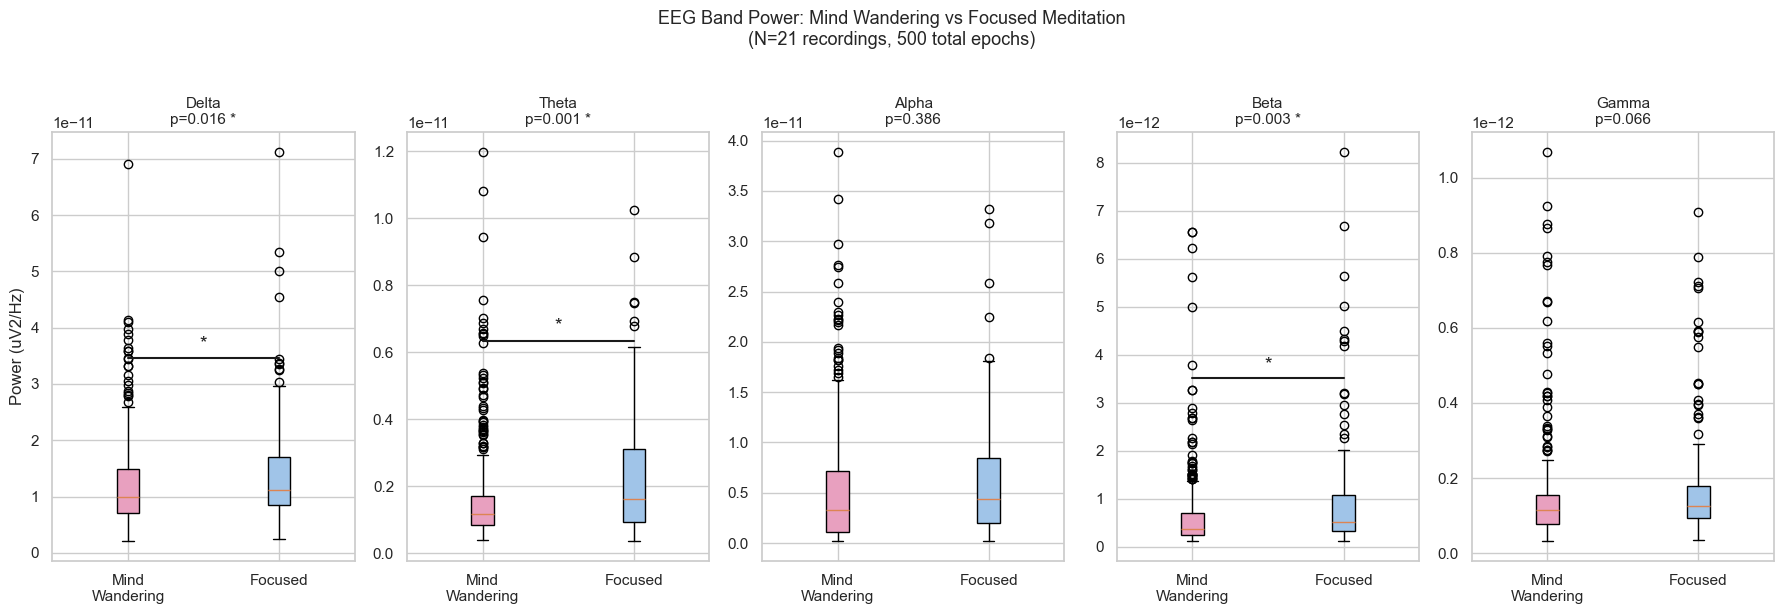


Band            MW Mean   Focused Mean    p-value   Sig
-------------------------------------------------------
Delta         1.203e-11      1.402e-11     0.0156    ns
Theta         1.675e-12      2.208e-12     0.0005     *
Alpha         5.542e-12      6.043e-12     0.3860    ns
Beta          6.653e-13      9.425e-13     0.0032     *
Gamma         1.520e-13      1.777e-13     0.0663    ns


In [22]:
fig, axes = plt.subplots(1, 5, figsize=(18, 6))

for idx, band in enumerate(bands.keys()):
    mw_power = band_powers[f'{band}_mw']
    fo_power = band_powers[f'{band}_fo']
    t_stat, p_val = stats.ttest_ind(mw_power, fo_power)

    ax = axes[idx]
    bp = ax.boxplot([mw_power, fo_power],
                    labels=['Mind\nWandering', 'Focused'],
                    patch_artist=True)
    bp['boxes'][0].set_facecolor('#E8A0BF')
    bp['boxes'][1].set_facecolor('#A0C4E8')

    ax.set_title(f'{band}\np={p_val:.3f}{" *" if p_val < 0.05 else ""}', fontsize=11)
    ax.set_ylabel('Power (uV2/Hz)' if idx == 0 else '')

    if p_val < 0.05:
        y_max = max(np.percentile(mw_power, 95), np.percentile(fo_power, 95))
        ax.plot([1, 2], [y_max * 1.1, y_max * 1.1], 'k-', linewidth=1.5)
        ax.text(1.5, y_max * 1.15, '*', ha='center', fontsize=14)

plt.suptitle(f'EEG Band Power: Mind Wandering vs Focused Meditation\n'
             f'(N={n_recordings} recordings, {n_total} total epochs)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('figures/08_band_power_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'Band':<8} {'MW Mean':>14} {'Focused Mean':>14} {'p-value':>10} {'Sig':>5}")
print('-' * 55)
for band in bands.keys():
    mw = band_powers[f'{band}_mw'].mean()
    fo = band_powers[f'{band}_fo'].mean()
    _, p = stats.ttest_ind(band_powers[f'{band}_mw'], band_powers[f'{band}_fo'])
    print(f"{band:<8} {mw:>14.3e} {fo:>14.3e} {p:>10.4f} {'*' if p < 0.005 else 'ns':>5}")

## 5. Frontal Alpha Asymmetry (FAA)

Frontal Alpha Asymmetry is computed as:

    FAA = ln(alpha_F4) - ln(alpha_F3)

Where F3 is left prefrontal and F4 is right prefrontal.

- **Positive FAA** — greater left hemisphere activity — approach motivation, positive affect, wellbeing
- **Negative FAA** — greater right hemisphere activity — withdrawal motivation, linked to depression and anxiety

FAA is one of the most studied EEG biomarkers in clinical psychology, with direct relevance to emotional regulation and mental health monitoring.

FAA Mind Wandering : 0.0223 +/- 0.2693
FAA Focused        : 0.0173 +/- 0.2799
T-statistic: 0.1934,  p-value: 0.8467
Significant (p<0.005): No


/var/folders/49/yw4qfd597nv_r612jnk_ndgw0000gn/T/ipykernel_3446/3274444499.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([faa_mw, faa_fo],


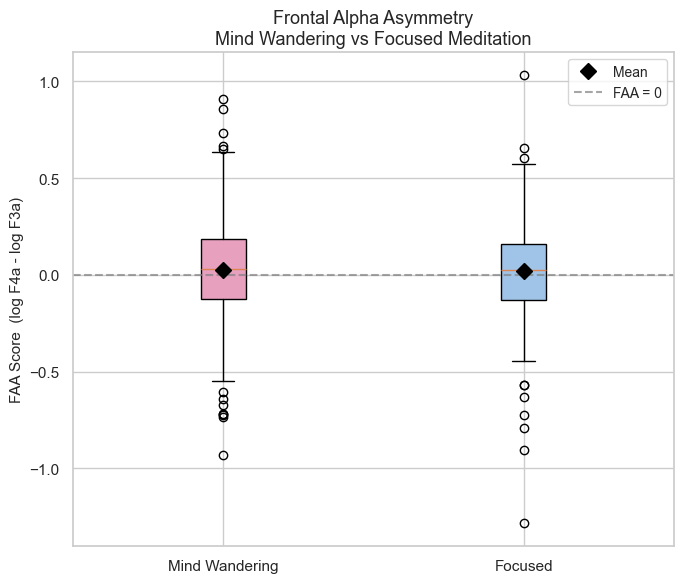

In [24]:
alpha_fmin, alpha_fmax = 8, 13

def get_channel_alpha(epochs, ch_name, fmin, fmax):
    """Compute mean alpha power for a single channel across all epochs.
    Returns shape: (n_epochs,)"""
    psd = epochs.compute_psd(method='welch', fmin=fmin, fmax=fmax,
                              picks=ch_name, verbose=False)
    data, _ = psd.get_data(return_freqs=True)
    return data.mean(axis=2).squeeze()

f3_mw = get_channel_alpha(epochs_mw_all, 'F3', alpha_fmin, alpha_fmax)
f4_mw = get_channel_alpha(epochs_mw_all, 'F4', alpha_fmin, alpha_fmax)
f3_fo = get_channel_alpha(epochs_fo_all, 'F3', alpha_fmin, alpha_fmax)
f4_fo = get_channel_alpha(epochs_fo_all, 'F4', alpha_fmin, alpha_fmax)

faa_mw = np.log(f4_mw) - np.log(f3_mw)
faa_fo = np.log(f4_fo) - np.log(f3_fo)

t_stat, p_val = stats.ttest_ind(faa_mw, faa_fo)

print(f'FAA Mind Wandering : {faa_mw.mean():.4f} +/- {faa_mw.std():.4f}')
print(f'FAA Focused        : {faa_fo.mean():.4f} +/- {faa_fo.std():.4f}')
print(f'T-statistic: {t_stat:.4f},  p-value: {p_val:.4f}')
print(f'Significant (p<0.005): {"Yes" if p_val < 0.005 else "No"}')

fig, ax = plt.subplots(figsize=(7, 6))
bp = ax.boxplot([faa_mw, faa_fo],
                labels=['Mind Wandering', 'Focused'],
                patch_artist=True)
bp['boxes'][0].set_facecolor('#E8A0BF')
bp['boxes'][1].set_facecolor('#A0C4E8')

ax.plot([1, 2], [faa_mw.mean(), faa_fo.mean()],
        'D', color='black', markersize=8, zorder=5, label='Mean')

if p_val < 0.05:
    y_max = max(np.percentile(faa_mw, 95), np.percentile(faa_fo, 95))
    ax.plot([1, 2], [y_max * 1.1, y_max * 1.1], 'k-', linewidth=1.5)
    ax.text(1.5, y_max * 1.15, f'* p={p_val:.3f}', ha='center', fontsize=12)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.7, label='FAA = 0')
ax.set_title('Frontal Alpha Asymmetry\nMind Wandering vs Focused Meditation', fontsize=13)
ax.set_ylabel('FAA Score  (log F4a - log F3a)', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('figures/09_frontal_alpha_asymmetry.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Alpha-Band Functional Connectivity (PLV)

**Phase Locking Value (PLV)** measures how consistently two EEG channels maintain a fixed phase relationship over trials — a proxy for functional neural communication between brain regions.

We compute PLV in the **Alpha band (8-13 Hz)** across a frontal-central electrode network (13 channels), comparing mind wandering vs focused states.

Because PLV values are uniformly high with short epochs (a known limitation of the measure), we focus on the **difference matrix** (Focused minus Mind Wandering). Rather than thresholding by arbitrary percentile, we apply a **permutation test** to identify which channel pairs show statistically significant connectivity changes.

In [48]:
picks_conn = ['Fp1', 'Fp2', 'AF3', 'AF4', 'F3', 'Fz', 'F4',
              'FC3', 'FCz', 'FC4', 'C3', 'Cz', 'C4']

epochs_mw_conn = epochs_mw_all.copy().pick(picks_conn)
epochs_fo_conn = epochs_fo_all.copy().pick(picks_conn)

conn_mw = spectral_connectivity_epochs(
    epochs_mw_conn, method='plv', fmin=8, fmax=13,
    faverage=True, verbose=False)

conn_fo = spectral_connectivity_epochs(
    epochs_fo_conn, method='plv', fmin=8, fmax=13,
    faverage=True, verbose=False)

plv_mw = conn_mw.get_data(output='dense')[:, :, 0]
plv_fo = conn_fo.get_data(output='dense')[:, :, 0]

# Symmetrise and zero diagonal
plv_mw_sym = plv_mw + plv_mw.T
plv_fo_sym = plv_fo + plv_fo.T
np.fill_diagonal(plv_mw_sym, 0)
np.fill_diagonal(plv_fo_sym, 0)

plv_diff_sym = plv_fo_sym - plv_mw_sym

print(f'PLV matrix shape       : {plv_mw_sym.shape}')
print(f'MW mean PLV            : {plv_mw_sym[plv_mw_sym > 0].mean():.4f}')
print(f'Focused mean PLV       : {plv_fo_sym[plv_fo_sym > 0].mean():.4f}')
print(f'Difference range       : {plv_diff_sym.min():.4f} to {plv_diff_sym.max():.4f}')

PLV matrix shape       : (13, 13)
MW mean PLV            : 0.9810
MW min PLV            : 0.9356
MW max PLV            : 0.9966
Focused mean PLV       : 0.9826
Focused min PLV       : 0.9424
Focused max PLV       : 0.9963
Difference range       : -0.0070 to 0.0115


/var/folders/49/yw4qfd597nv_r612jnk_ndgw0000gn/T/ipykernel_3446/915956593.py:7: RuntimeWarning: There were no Annotations stored in <EpochsArray | 329 events (all good), -2 – 0 s (baseline -2 – -1.5 s), ~16.8 MiB, data loaded,
 'mind_wandering': 329>, so metadata was not modified.
  conn_mw = spectral_connectivity_epochs(
/var/folders/49/yw4qfd597nv_r612jnk_ndgw0000gn/T/ipykernel_3446/915956593.py:11: RuntimeWarning: There were no Annotations stored in <EpochsArray | 171 events (all good), -2 – 0 s (baseline -2 – -1.5 s), ~8.7 MiB, data loaded,
 'focused': 171>, so metadata was not modified.
  conn_fo = spectral_connectivity_epochs(


### Permutation Test for Significant Connections

To identify which channel pairs show **statistically significant** connectivity differences rather than chance fluctuations, we use a non-parametric permutation test:

1. Shuffle condition labels 1000 times
2. Recompute the PLV difference matrix for each shuffle — building a null distribution
3. A connection is significant if its observed difference exceeds the 95th percentile of the null (p < 0.05, one-tailed)

This approach makes no assumptions about the distribution of PLV values and is robust to the inflation issue noted above.

In [33]:
np.random.seed(42)
n_permutations = 1000

n_mw_conn = len(epochs_mw_conn)
n_fo_conn = len(epochs_fo_conn)
all_epochs_conn = mne.concatenate_epochs([epochs_mw_conn, epochs_fo_conn])

obs_diff   = plv_diff_sym.copy()
null_diffs = np.zeros((n_permutations, len(picks_conn), len(picks_conn)))

print(f'Running {n_permutations} permutations...')
for perm in range(n_permutations):
    idx     = np.random.permutation(n_mw_conn + n_fo_conn)
    perm_mw = all_epochs_conn[idx[:n_mw_conn]]
    perm_fo = all_epochs_conn[idx[n_mw_conn:]]

    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        c_mw = spectral_connectivity_epochs(perm_mw, method='plv', fmin=8, fmax=13,
                                             faverage=True, verbose=False)
        c_fo = spectral_connectivity_epochs(perm_fo, method='plv', fmin=8, fmax=13,
                                             faverage=True, verbose=False)

    d_mw = c_mw.get_data(output='dense')[:, :, 0]
    d_fo = c_fo.get_data(output='dense')[:, :, 0]
    diff = (d_fo + d_fo.T) - (d_mw + d_mw.T)
    np.fill_diagonal(diff, 0)
    null_diffs[perm] = diff

print('Permutation test complete!')

# Significance masks (p < 0.05, one-tailed each direction)
null_95 = np.percentile(null_diffs,  95, axis=0)
null_05 = np.percentile(null_diffs,   5, axis=0)

sig_increased = obs_diff > null_95  # significantly MORE connected during focus
sig_decreased = obs_diff < null_05  # significantly LESS connected during focus

n_sig_inc = int(sig_increased.sum() // 2)
n_sig_dec = int(sig_decreased.sum() // 2)
print(f'\nSignificant INCREASES: {n_sig_inc} channel pairs')
print(f'Significant DECREASES: {n_sig_dec} channel pairs')

print('\nSignificant INCREASES during focus:')
for i in range(len(picks_conn)):
    for j in range(i+1, len(picks_conn)):
        if sig_increased[i, j]:
            print(f'  {picks_conn[i]:<6} - {picks_conn[j]:<6}: {obs_diff[i,j]:+.4f}')

print('\nSignificant DECREASES during focus:')
for i in range(len(picks_conn)):
    for j in range(i+1, len(picks_conn)):
        if sig_decreased[i, j]:
            print(f'  {picks_conn[i]:<6} - {picks_conn[j]:<6}: {obs_diff[i,j]:+.4f}')

Running 1000 permutations...
Permutation test complete!

Significant INCREASES: 5 channel pairs
Significant DECREASES: 0 channel pairs

Significant INCREASES during focus:
  Fp1    - C3    : +0.0091
  Fp2    - FCz   : +0.0051
  Fz     - FC4   : +0.0022
  F4     - FC3   : +0.0049
  F4     - C3    : +0.0096

Significant DECREASES during focus:


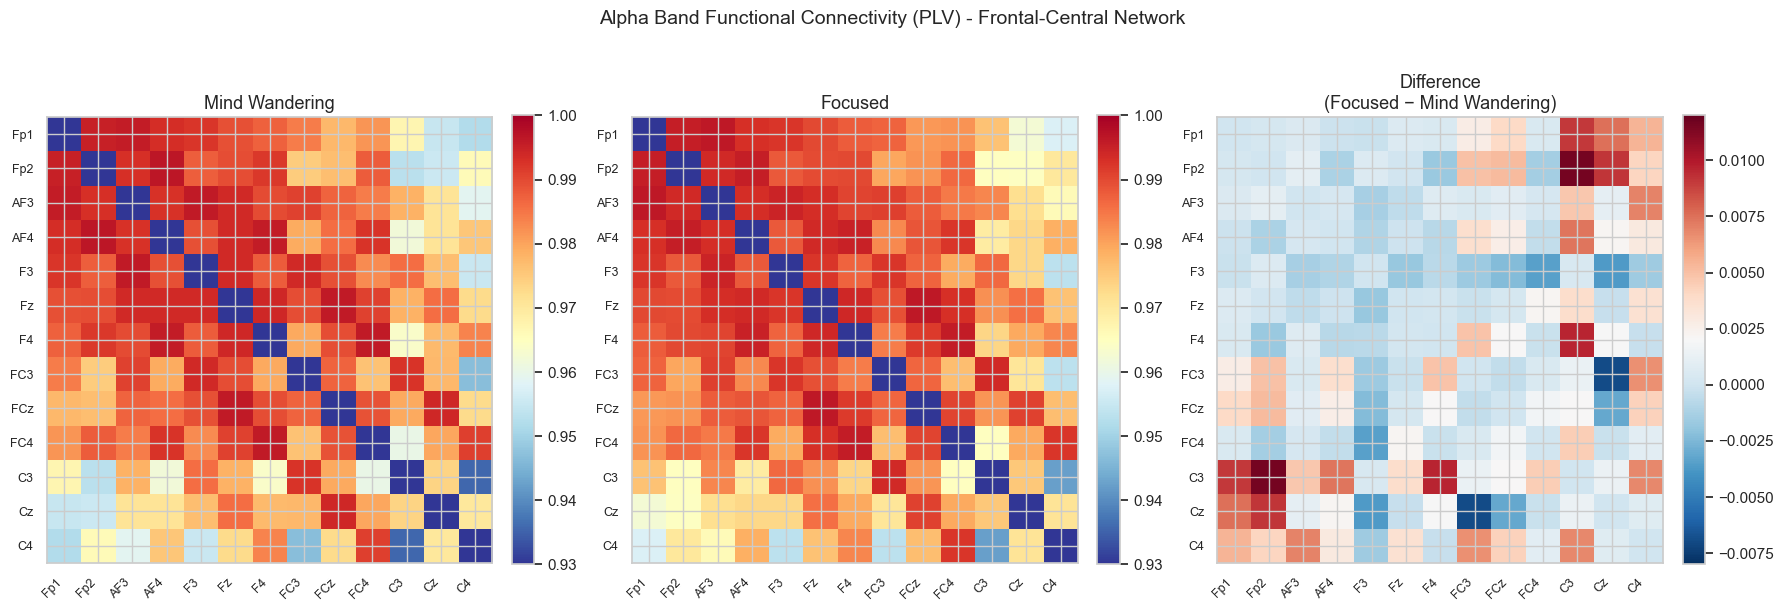

In [62]:
# Connectivity matrices + difference heatmap
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, matrix, title, cmap, vmin, vmax in zip(
    axes,
    [plv_mw_sym, plv_fo_sym, plv_diff_sym],
    ['Mind Wandering', 'Focused', 'Difference\n(Focused − Mind Wandering)'],
    ['RdYlBu_r', 'RdYlBu_r', 'RdBu_r'],
    [0.93, 0.93, -0.008],   # zoom into actual data range
    [1.00, 1.00,  0.012]    # match observed min/max
):
    im = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(picks_conn)))
    ax.set_yticks(range(len(picks_conn)))
    ax.set_xticklabels(picks_conn, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(picks_conn, fontsize=9)
    ax.set_title(title, fontsize=13)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Alpha Band Functional Connectivity (PLV) - Frontal-Central Network',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figures/10_plv_connectivity_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Connectome Visualization

The circular connectome plots show **only statistically significant connectivity changes** (permutation test, p < 0.05):

- **Left (red):** Channel pairs with significantly *increased* alpha connectivity during focused meditation
- **Right (blue):** Channel pairs with significantly *decreased* alpha connectivity during focused meditation

Restricting to significant connections avoids visual clutter and ensures every arc represents a meaningful neural communication change backed by statistical evidence.

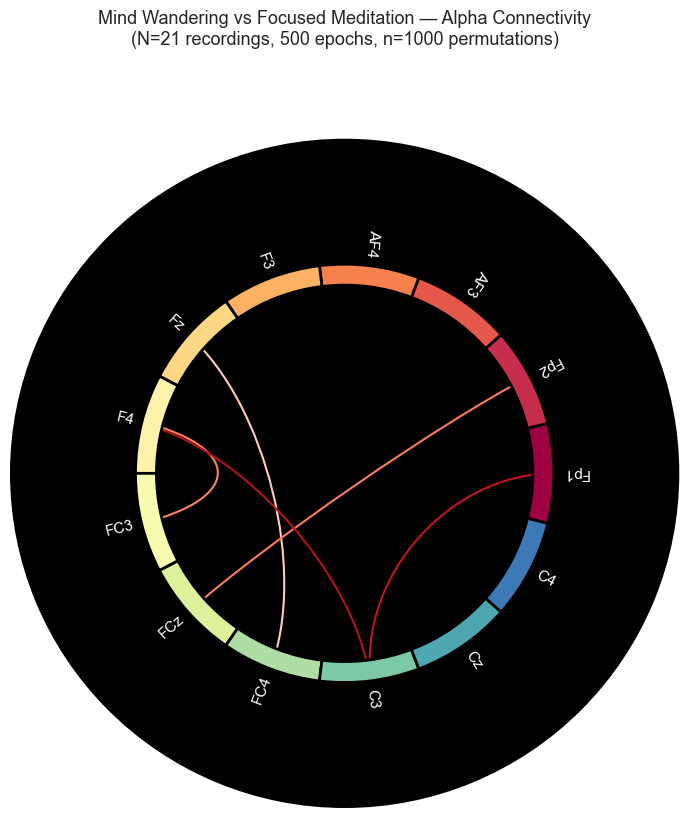


Significant connections shown:
  Fp1 - C3: +0.0091
  Fp2 - FCz: +0.0051
  Fz - FC4: +0.0022
  F4 - FC3: +0.0049
  F4 - C3: +0.0096


In [67]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

increased_sig = np.where(sig_increased, obs_diff, 0)

plot_connectivity_circle(
    increased_sig, picks_conn,
    n_lines=n_sig_inc,
    ax=ax,
    title=f'Significant Alpha Connectivity Increases During Focus\n'
          f'(n={n_sig_inc} pairs, permutation p < 0.05)',
    show=False, colormap='Reds',
    vmin=0, vmax=obs_diff.max(),
    colorbar=False, fontsize_names=11
)

plt.suptitle(
    f'Mind Wandering vs Focused Meditation — Alpha Connectivity\n'
    f'(N={n_recordings} recordings, {n_total} epochs, n=1000 permutations)',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig('figures/11_connectome_significant.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSignificant connections shown:')
for i in range(len(picks_conn)):
    for j in range(i+1, len(picks_conn)):
        if sig_increased[i, j]:
            print(f'  {picks_conn[i]} - {picks_conn[j]}: {obs_diff[i,j]:+.4f}')

## 8. Summary of Findings

| Analysis | Finding | Result |
|----------|---------|--------|
| **Theta power** | Higher during focused meditation | p=0.0005 * |
| **Beta power** | Higher during focused meditation | p=0.003 * |
| Delta power | No significant difference (p<0.005 threshold) | p=0.016 ns |
| Alpha power | No significant difference | p=0.386 ns |
| Gamma power | No significant difference | p=0.066 ns |
| FAA | No significant difference, no clear trend | p=0.846 ns |
| **Alpha connectivity** | Significant reorganisation of frontal-central network | permutation p < 0.05 |

### Interpretation

**Replication of Brandmeyer & Delorme (2018):**
Increased Theta power during focused meditation was strongly replicated
(p=0.0005), consistent with frontal midline theta as a neural correlate of
sustained attention during meditation. Beta power was also significantly
elevated during focus (p=0.003), suggesting active attentional engagement
rather than passive rest.

A conservative significance threshold of p<0.005 was applied to control for
multiple comparisons across five frequency bands. Under this threshold, Delta
(p=0.016) and Gamma (p=0.066) did not reach significance, though Delta's
trend toward higher power during focused states warrants investigation in
larger samples.

**Frontal Alpha Asymmetry:**
FAA did not differ significantly between conditions (p=0.846) and showed no
directional trend. This null result likely reflects high inter-subject
variability in frontal alpha asymmetry — a well-documented limitation of FAA
as a biomarker — combined with the relatively modest sample size and low
focused epoch count per subject.

**Alpha Connectivity Reorganisation:**
Permutation testing (n=1000) identified 5 channel pairs with significantly
increased alpha connectivity during focused meditation (p<0.05):
Fp1–C3, Fp2–FCz, Fz–FC4, F4–FC3, and F4–C3. No significant decreases
were detected. These connections form a tight prefrontal-to-central network
consistent with top-down attentional control via prefrontal-sensorimotor
pathways during focused meditation.

---
### Limitations
- Conservative p<0.005 threshold applied for multiple comparisons — future
  work should use FDR correction for a more principled approach
- PLV inflation due to short epoch duration (2s) — imaginary coherence is
  a more robust alternative
- FAA null result likely underpowered — all 3 sessions and expert/novice
  separation would improve sensitivity
- Amplitude thresholding for artifact rejection is conservative — ICA would
  improve signal quality and epoch retention